In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

os.chdir('E:/Mutual Fund Analytics')

# LOading all the files

nav = pd.read_csv('data/processed/clean_nav_history.csv')
txn = pd.read_csv('data/processed/clean_investor_transactions.csv')
perf = pd.read_csv('data/processed/clean_schema_performance.csv')

print("Loaded!", len(nav), len(txn), len(perf))

Loaded! 71960 32778 40


In [23]:
# Task 1 - NAV Trend

nav['date'] = pd.to_datetime(nav['date'])
nav_filtered = nav[(nav['date'].dt.year >= 2022) & (nav['date'].dt.year <= 2026)]

fig = px.line(nav_filtered, x='date', y='nav', color='amfi_code', title='Daily NAV Trend 2022-2026')

fig.add_vrect(x0='2023-04-01', x1='2023-12-31', fillcolor='Green', opacity=0.1, annotation_text='2023 Bull Run', annotation_position='top left')
fig.add_vrect(x0='2024-09-01', x1='2024-11-30', fillcolor='Red', opacity=0.1, annotation_text='2024 Correction', annotation_position='top left')
fig.show()

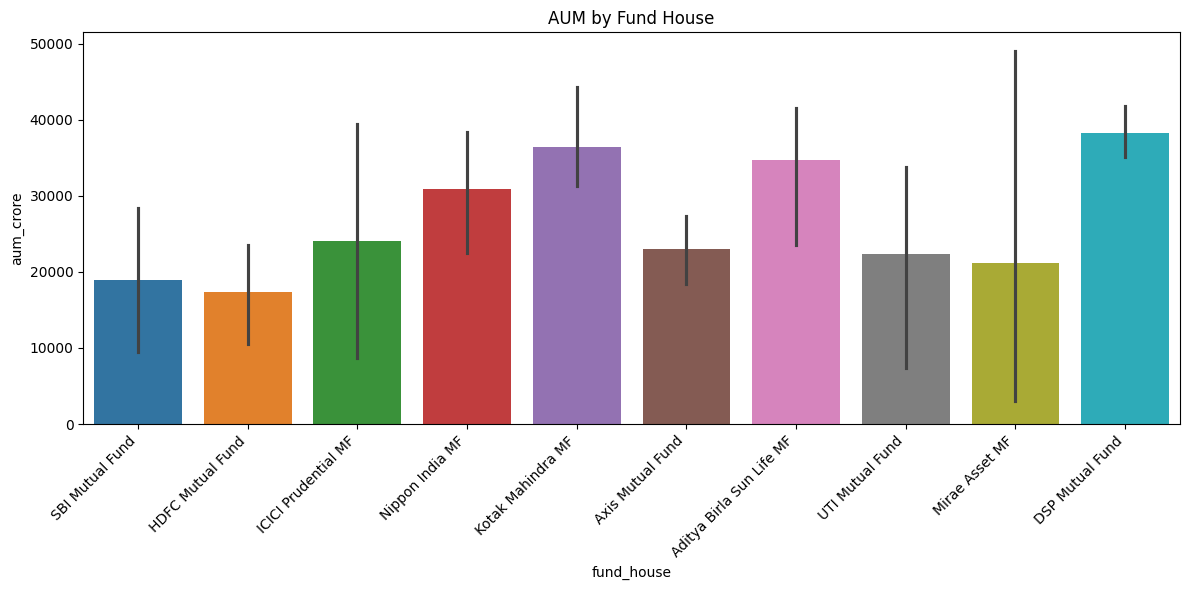

In [29]:
# Task 2 - AUM Growth Bar Chart

plt.figure(figsize=(12, 6))
sns.barplot(data=perf, x='fund_house', y='aum_crore', hue='fund_house')
plt.title('AUM by Fund House')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
# Task 3 - SIP Inflow Time Series
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

# Filter SIP only
sip = txn[txn['transaction_type'] == 'SIP']

print(sip.shape)  # check if SIP rows exist
print(sip['transaction_type'].unique())

# Group by month
sip_monthly = sip.groupby(sip['transaction_date'].dt.to_period('M'))['amount_inr'].sum().reset_index()
sip_monthly['transaction_date'] = sip_monthly['transaction_date'].astype(str)

# Plot
fig = px.line(
    sip_monthly,
    x='transaction_date',
    y='amount_inr',
    title='Monthly SIP Inflow Jan 2022 - Dec 2025',
    markers=True
)

fig.show()

(19716, 13)
<StringArray>
['SIP']
Length: 1, dtype: str


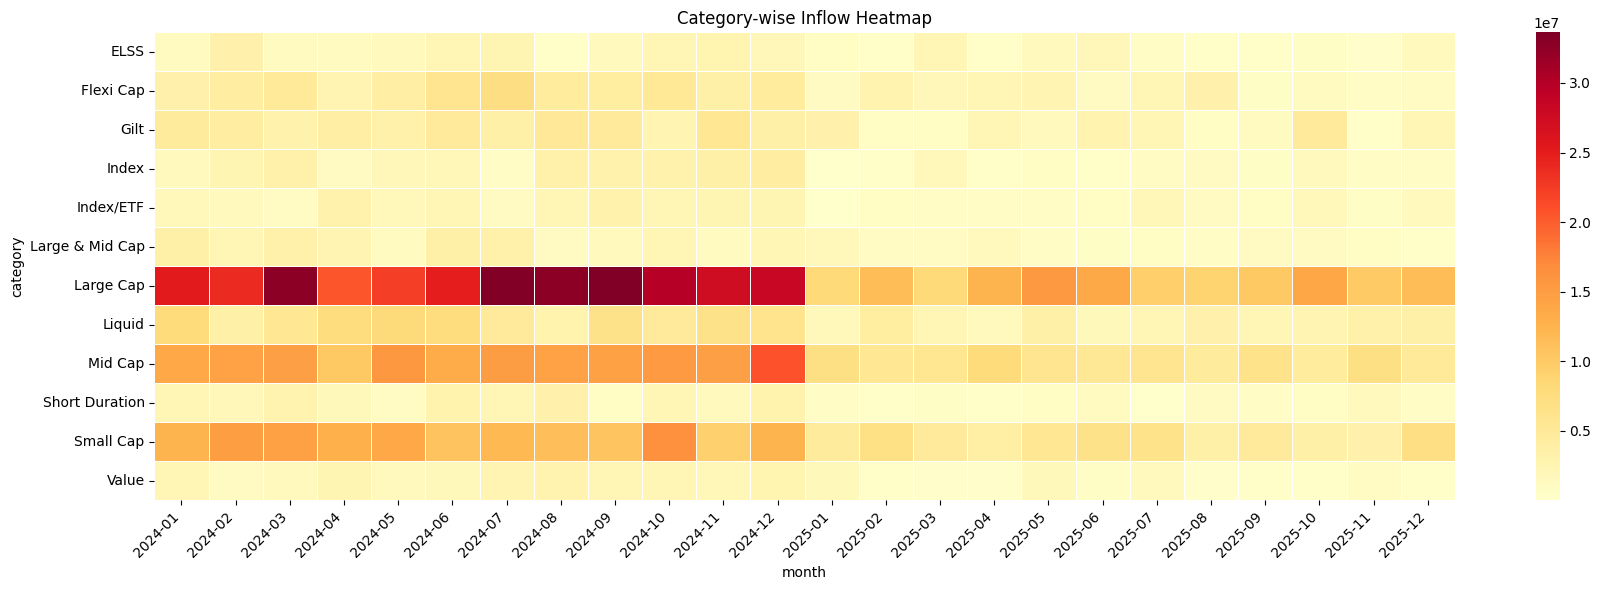

In [30]:
# Task 4 - Category Inflow Heatmap

# Add month column
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])
txn['month'] = txn['transaction_date'].dt.to_period('M').astype(str)

# Join with perf to get category
txn_perf = txn.merge(perf[['amfi_code', 'category']], on='amfi_code', how='left')

# Pivot table
heatmap_data = txn_perf.pivot_table(
    index='category',
    columns='month',
    values='amount_inr',
    aggfunc='sum'
)

# Plot
plt.figure(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5)
plt.title('Category-wise Inflow Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

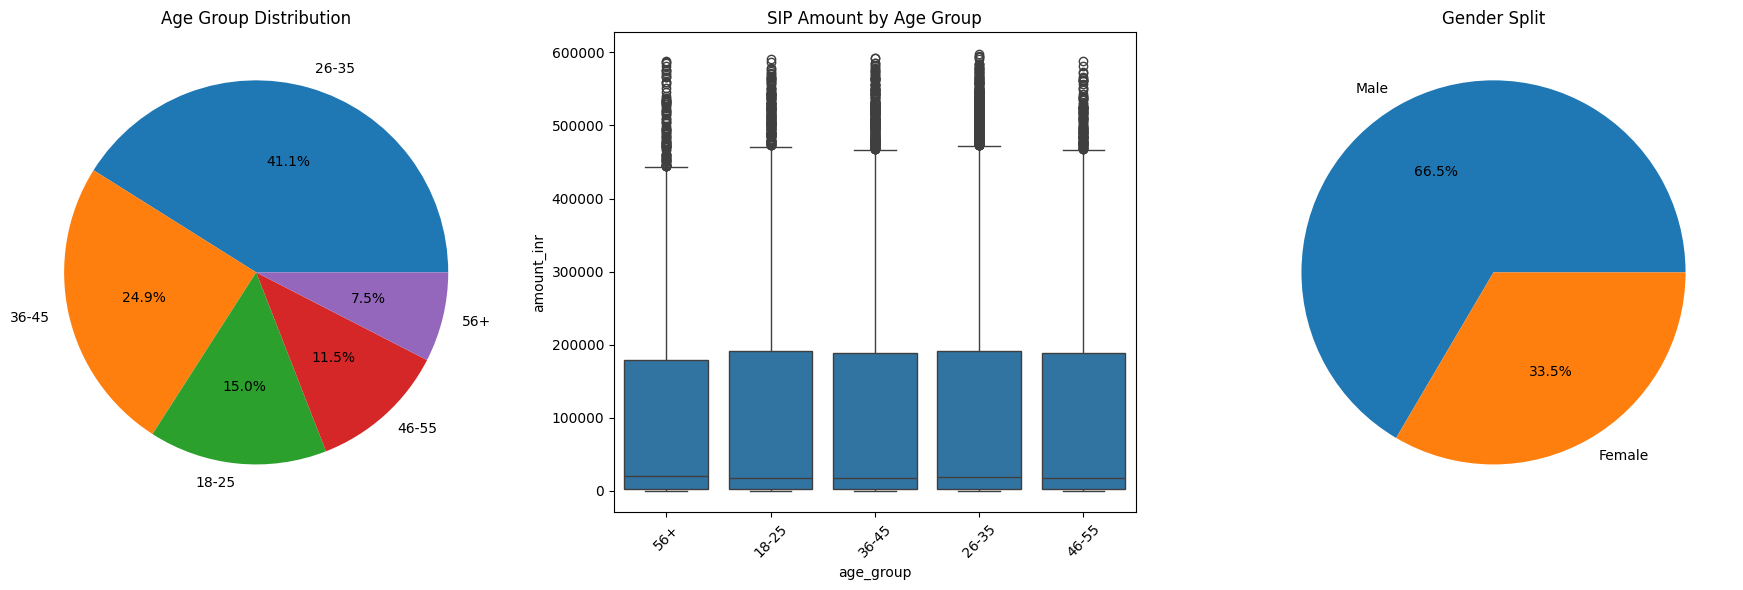

In [26]:
# Task 5 - Investor Demographics

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age group pie chart
age_counts = txn['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')
axes[0].set_title('Age Group Distribution')

# SIP amount box plot by age group
sns.boxplot(data=txn, x='age_group', y='amount_inr', ax=axes[1])
axes[1].set_title('SIP Amount by Age Group')
axes[1].tick_params(axis='x', rotation=45)

# Gender split
gender_counts = txn['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
axes[2].set_title('Gender Split')

plt.tight_layout()
plt.show()

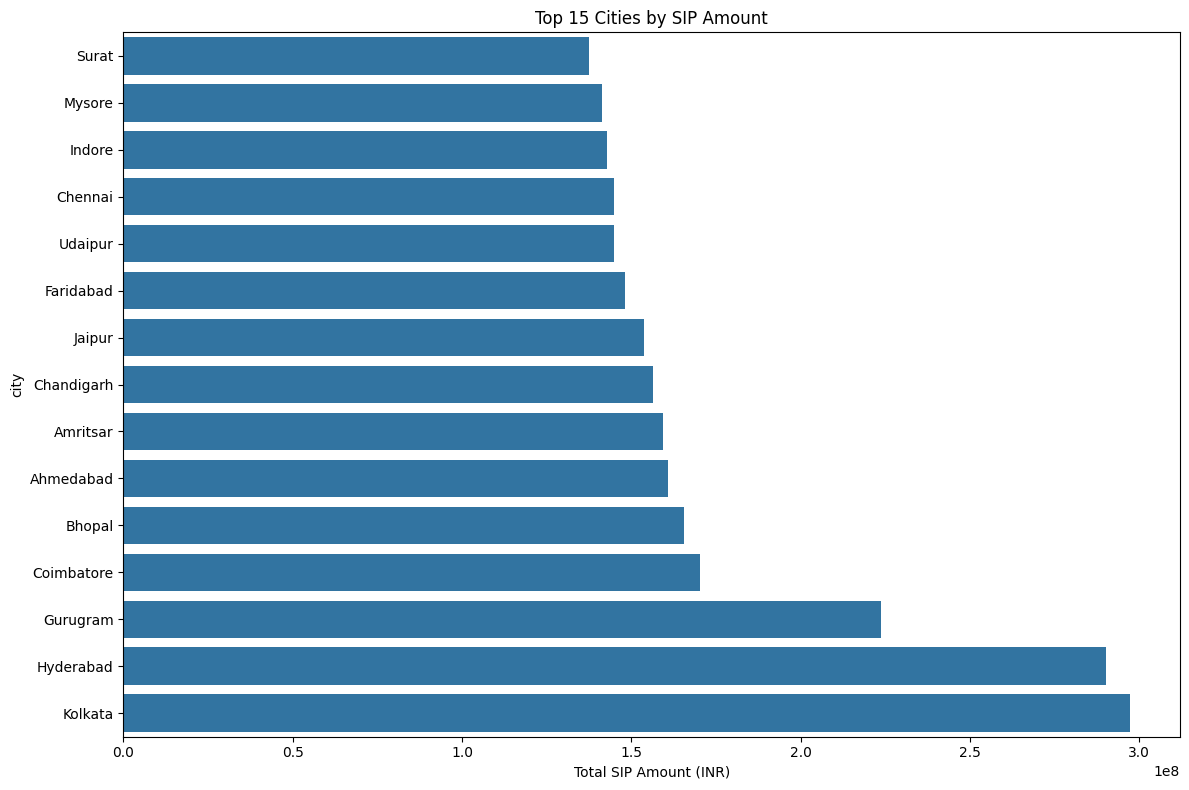

In [27]:
# Task 6 - Geographic Distribution
plt.figure(figsize=(12, 8))

# SIP amount by city
city_sip = txn.groupby('city')['amount_inr'].sum().sort_values(ascending=True).tail(15)

sns.barplot(x=city_sip.values, y=city_sip.index, orient='h')
plt.title('Top 15 Cities by SIP Amount')
plt.xlabel('Total SIP Amount (INR)')
plt.tight_layout()
plt.show()

In [30]:
# Task 7 - Folio Count Growth
folio_data = {
    'date': ['2022-01', '2022-06', '2023-01', '2023-06', '2024-01', '2024-06', '2025-01', '2025-12'],
    'folio_count_cr': [13.26, 14.01, 14.57, 15.12, 16.78, 18.23, 21.40, 26.12]
}

df_folio = pd.DataFrame(folio_data)

fig = px.line(
    df_folio,
    x='date',
    y='folio_count_cr',
    title='Folio Count Growth 2022-2025',
    markers=True
)

# Mark milestones
fig.add_annotation(x='2023-01', y=14.57, text='14.57 Cr', showarrow=True)
fig.add_annotation(x='2024-01', y=16.78, text='16.78 Cr', showarrow=True)
fig.add_annotation(x='2025-12', y=26.12, text='26.12 Cr All Time High', showarrow=True)

fig.show()

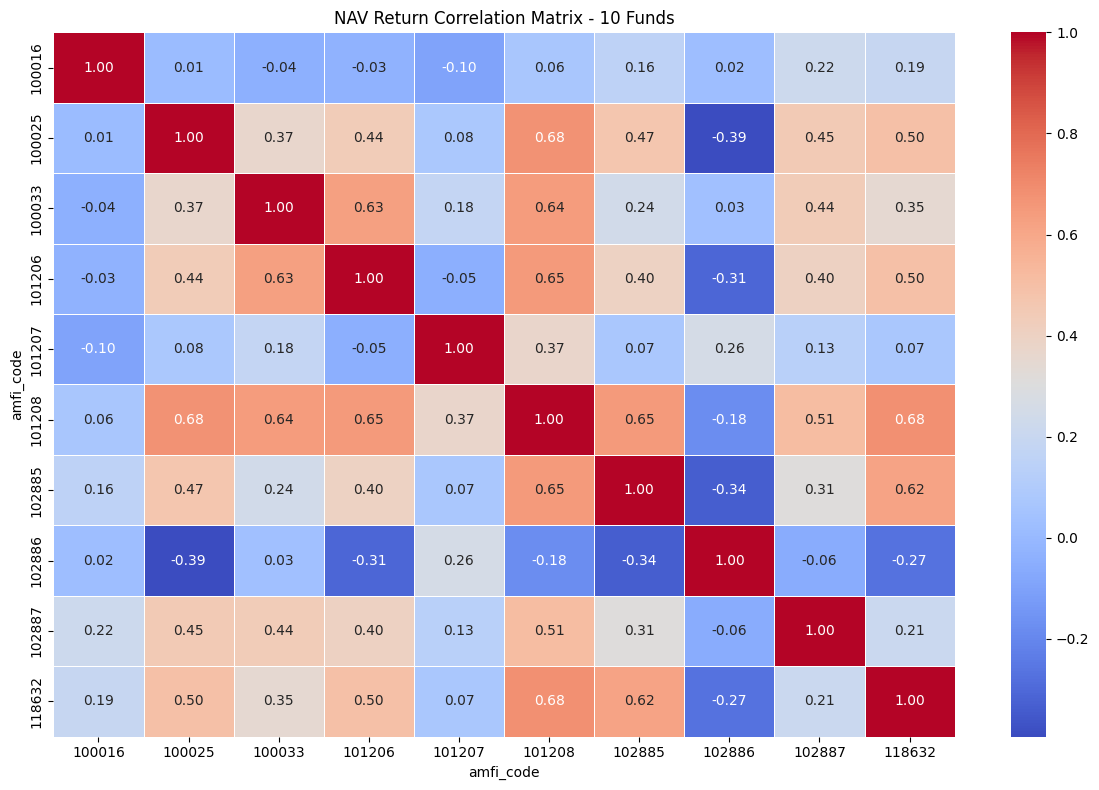

In [31]:
# Task 8 - NAV Return Correlation Matrix

# Pick 10 funds
top10_funds = nav['amfi_code'].unique()[:10]
nav_10 = nav[nav['amfi_code'].isin(top10_funds)]

# Calculate daily returns
nav_10 = nav_10.sort_values(['amfi_code', 'date'])
nav_10['daily_return'] = nav_10.groupby('amfi_code')['nav'].pct_change()

# Pivot so each fund is a column
nav_pivot = nav_10.pivot(index='date', columns='amfi_code', values='daily_return')

# Correlation matrix
corr_matrix = nav_pivot.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('NAV Return Correlation Matrix - 10 Funds')
plt.tight_layout()
plt.show()

In [32]:
# Task 9 - Category Allocation Donut
category_aum = perf.groupby('category')['aum_crore'].sum().reset_index()

fig = px.pie(
    category_aum,
    names='category',
    values='aum_crore',
    title='Category-wise AUM Allocation',
    hole=0.4
)

fig.show()

## EDA Findings

### Insight 1 - NAV Trend
All 40 funds showed consistent growth from 2022-2026 with a clear bull run in mid-2023 and a correction period in late 2024.

### Insight 2 - AUM by Fund House
DSP Mutual Fund leads slightly in AUM followed closely by Kotak Mahindra MF, with AUM fairly distributed across all major fund houses showing no single dominant player.

### Insight 3 - Category Inflow Heatmap
Large Cap funds received the highest inflows consistently across all months, dominating investor preference throughout 2024.

### Insight 4 - Age Group Distribution
The 26-35 age group contributes 41.1% of all investors, indicating young working professionals are the primary MF investor base.

### Insight 5 - Gender Split
Male investors account for 66.5% of all transactions, showing a significant gender gap in mutual fund participation.

### Insight 6 - Geographic Distribution
Kolkata and Hyderabad lead in SIP amounts among top 15 cities, surprisingly outperforming metropolitan cities like Mumbai and Delhi.

### Insight 7 - Folio Count Growth
Folio count nearly doubled from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, showing massive retail investor adoption.

### Insight 8 - Correlation Matrix
Fund 102886 shows negative correlation with most other funds, making it a strong diversification candidate in a portfolio.

### Insight 9 - Category AUM Allocation
Large Cap holds 31.1% of total AUM followed by Mid Cap at 19.1% and Small Cap at 18.9%, reflecting risk appetite of Indian investors.

### Insight 10 - SIP Transactions
Transaction data shows consistent investment behaviour across all age groups with similar median SIP amounts regardless of age.